# Product Segmentation with K-Means Clustering

**Retail supermarket "SWALAYAN KEADILAN" - 2025 POS receipts**

This notebook builds an end-to-end, reproducible machine-learning pipeline that
segments products by their sales behaviour using K-Means clustering. The heavy
lifting lives in the `src/` package; this notebook orchestrates the phases and
presents the results.

## 1. Introduction

Retailers carry thousands of products with very different sales dynamics. Grouping
them into a small number of behavioural segments supports inventory planning,
shelf placement, promotions, and pricing. We use **unsupervised** learning
(K-Means) because there are no pre-existing labels; the goal is interpretability,
not prediction.

In [1]:
# Make the `src` package importable regardless of the working directory.
import sys
from pathlib import Path

root = Path.cwd()
while not (root / "src").exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))

import pandas as pd
from IPython.display import Image, display

from src import config, parser, preprocessing, feature_engineering, visualization
from src.clustering import (
    scale_features, evaluate_k, select_optimal_k, fit_kmeans,
    build_cluster_profiles, run_segmented_clustering,
)

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
config.ensure_output_dirs()
print("Project root:", root)

Project root: E:\work\63.ml-k-means-clustering\repo


## 2. Problem Statement

Given raw Indonesian POS receipt logs, segment products into behavioural groups
using K-Means so the business can distinguish fast-moving, slow-moving, and
premium products and act on each group differently.

## 3. Dataset Description

* **Source:** `dataset/struk penjualan 2025/*.TXT` - 209 daily POS receipt logs.
* **Language / currency:** Indonesian; Indonesian Rupiah (IDR). Amounts use `.`
  as a thousands separator (`5.000` = 5000).
* **Receipt structure:** a transaction header line carries the datetime and
  receipt code; each product is a name line plus a quantity line; optional
  `Potongan` rows carry discounts; a trailing `**` marks excise (cukai) goods.

See `SPEC.md` for the full grammar and schema.

## 4. Data Parsing

Parse every receipt file into one row per product line.

In [2]:
transactions_raw = parser.parse_all()
print(f"{transactions_raw['source_file'].nunique()} files parsed")
print(f"{len(transactions_raw):,} product lines, "
      f"{transactions_raw['transaction_uid'].nunique():,} transactions, "
      f"{transactions_raw['product_code'].nunique():,} distinct products")
transactions_raw.head()

209 files parsed
52,067 product lines, 24,070 transactions, 1,735 distinct products


,source_file,station,transaction_id,transaction_uid,transaction_datetime,product_code,product_name,quantity,unit_price,line_total,line_discount,is_excise
0,02-20241227.TXT,02,O5BS/00001/1/AGG,02-20241227.TXT::O5BS/00001/1/AGG,2024-12-27 07:11:47,1320910,NARAYA KDLAI BTL320,1,6000,6000,0,False
1,02-20241227.TXT,02,O5BS/00002/1/AGG,02-20241227.TXT::O5BS/00002/1/AGG,2024-12-27 07:13:01,1492840,LARISST AIR MIN600ML,1,2000,2000,0,False
2,02-20241227.TXT,02,O5BS/00003/1/AGG,02-20241227.TXT::O5BS/00003/1/AGG,2024-12-27 07:13:15,0012690,AQUA AIR MINERAL1500,1,7000,7000,0,False
3,02-20241227.TXT,02,O5BS/00004/1/AGG,02-20241227.TXT::O5BS/00004/1/AGG,2024-12-27 07:15:21,0370270,WOODS PEP.EXT/STRG15,2,6700,13400,0,False
4,02-20241227.TXT,02,O5BS/00005/1/AGG,02-20241227.TXT::O5BS/00005/1/AGG,2024-12-27 07:16:50,1274950,LA ICE 16'S BKS,1,33800,33800,0,True


## 5. Data Cleaning

Remove duplicates, drop rows with missing/invalid fields, and validate
quantities and prices.

In [3]:
transactions, report = preprocessing.clean_transactions(transactions_raw)
print(report.summary())
transactions.to_csv(config.TRANSACTIONS_CSV, index=False)
transactions.describe(include="all").T

Cleaning: 52,067 -> 52,067 rows (dups -0, missing -0, bad qty -0, bad price -0)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
source_file,52067,209,02-20250224.TXT,1405,NaN,NaN,NaN,NaN,NaN,NaN,NaN
station,52067,1,02,52067,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transaction_id,52067,735,O5BS/00003/1/AGG,568,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transaction_uid,52067,24070,02-20250908.TXT::O5BS/00075/1/AGG,86,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transaction_datetime,52067,NaN,NaN,NaN,2025-06-02 07:22:51.765033,2024-12-27 07:11:47,2025-02-05 19:47:23,2025-06-02 07:40:30,2025-09-12 12:58:37.500000,2025-12-24 15:44:03,NaN
product_code,52067,1735,0357330,1206,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_name,52067,1823,SAMPOERNA MILD 16'S,1206,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quantity,"52,067.00",NaN,NaN,NaN,1.81,1.00,1.00,1.00,1.00,552.00,6.92
unit_price,"52,067.00",NaN,NaN,NaN,"14,189.64",800.00,"5,900.00","9,700.00","20,000.00","149,000.00","11,924.57"
line_total,"52,067.00",NaN,NaN,NaN,"19,644.51",0.00,"6,700.00","11,500.00","22,500.00","2,213,400.00","36,056.63"


## 6. Exploratory Data Analysis

Dataset dimensions, top products, and the distribution / correlation of the
sales features. Figures are written to `reports/figures/`.

Products: 1735

Top 10 products by revenue:


,product_name,total_quantity_sold,total_revenue,transaction_count
43,SAMPOERNA MILD 16'S,1511,55799600,1206
94,234 ROKOK KRT 12/PCS,1443,29498200,836
91,LA FILTER LIGHT 16'S,666,23389100,213
49,LE MINERALE 330ML,9120,20470350,359
180,DJI SAM SOE S/PRM,861,19873700,770
8,AQUA AIR MINERAL 330,7624,18689200,287
148,GG FILTER MERAH 12'S,589,15815200,284
55,DJI SAM SOE MGNUM 12,560,15322700,366
157,MARLBORO BLS/BRST 20,292,14949600,102
6,LE MINERALE 600ML,4011,13421000,1036


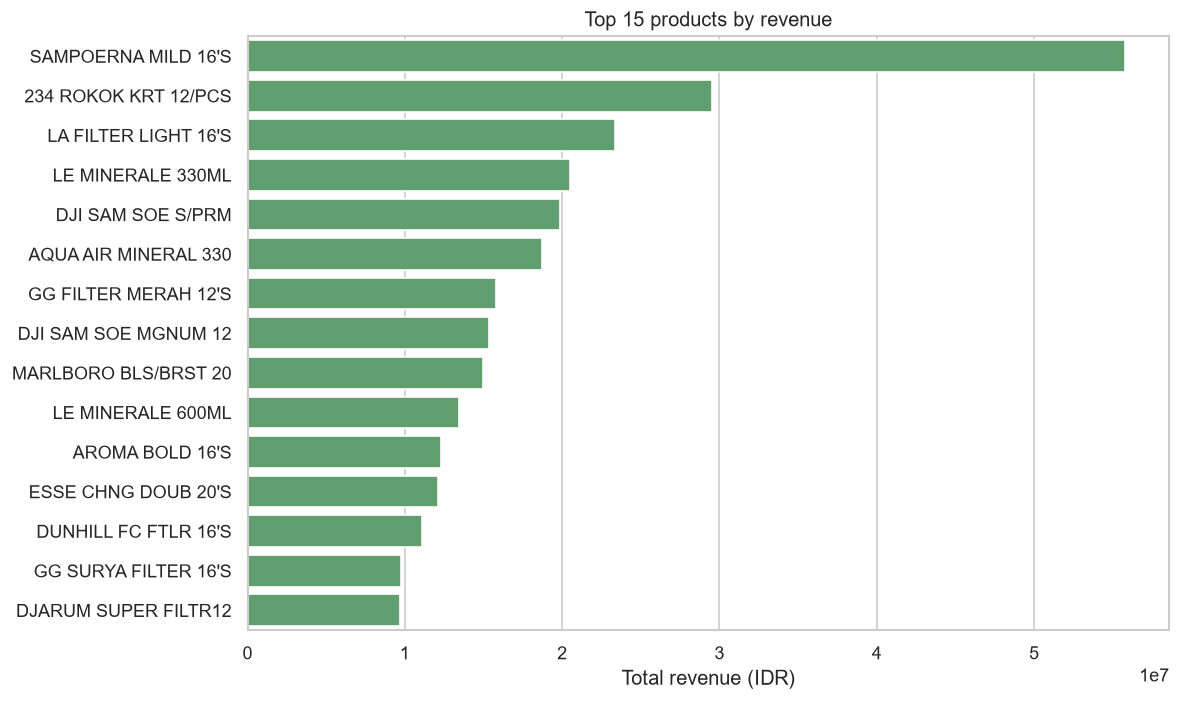

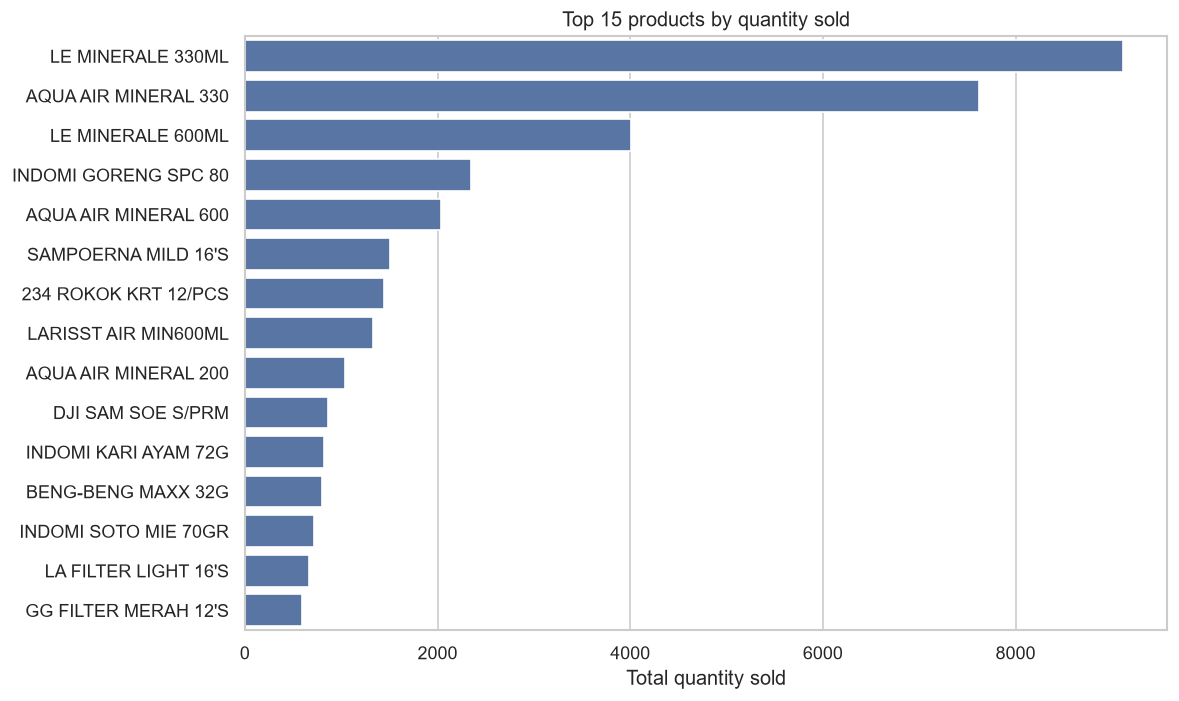

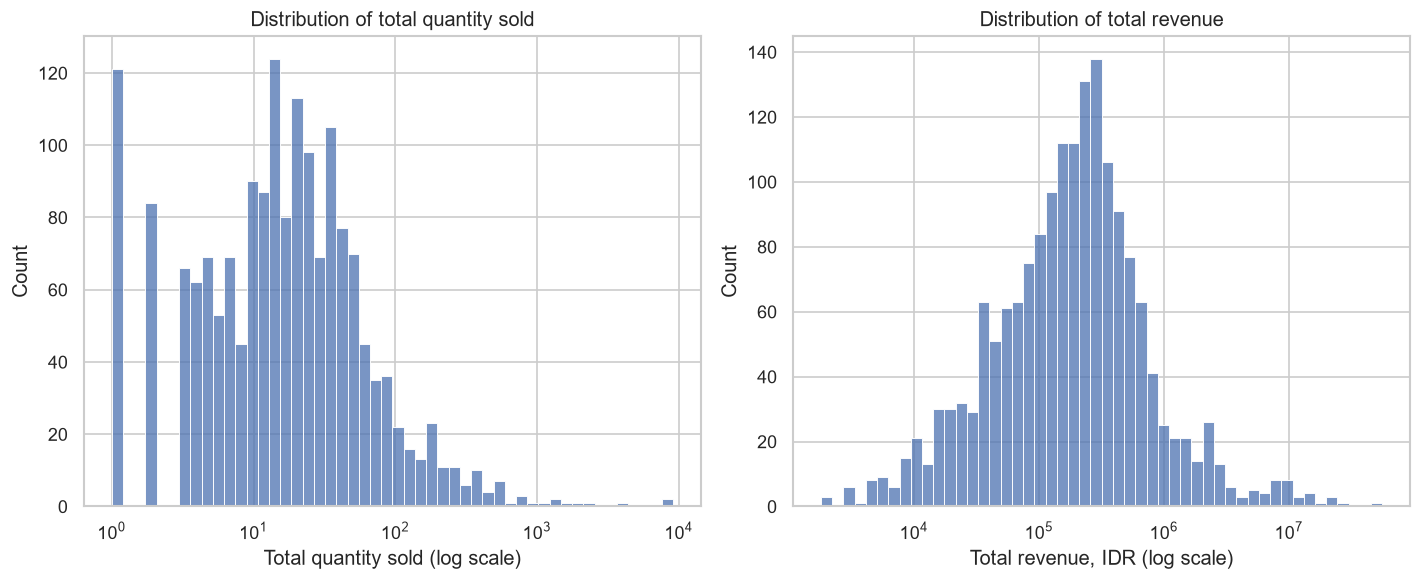

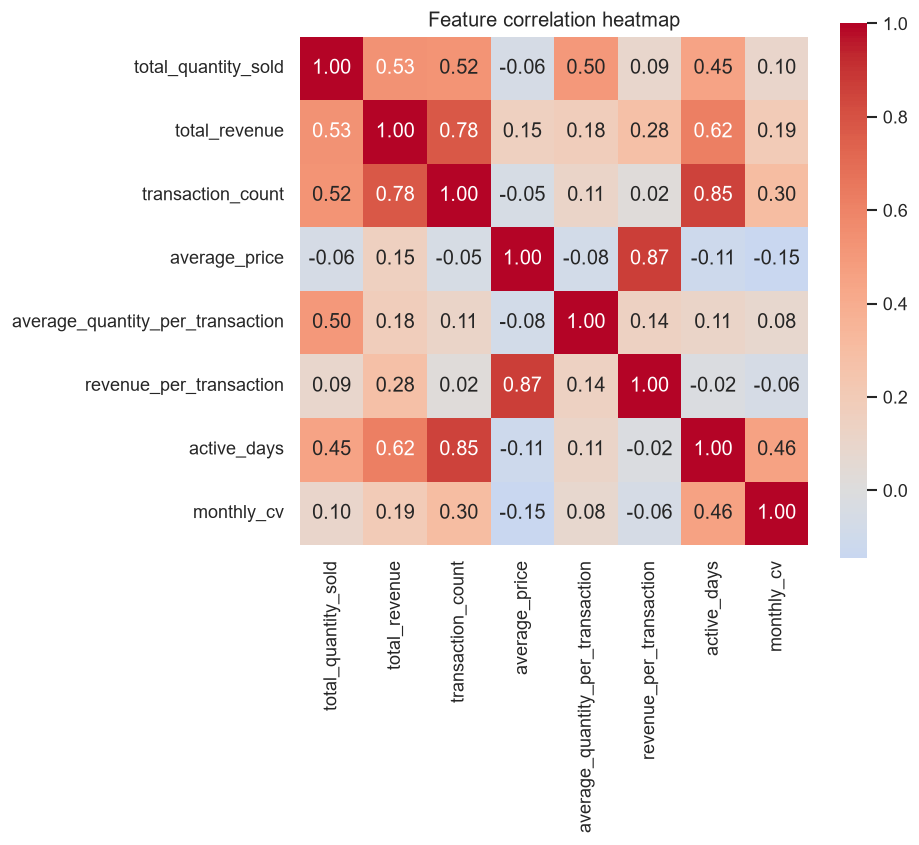

In [4]:
products_eda = feature_engineering.build_product_features(transactions)
print("Products:", len(products_eda))
print("\nTop 10 products by revenue:")
display(products_eda.nlargest(10, "total_revenue")[
    ["product_name", "total_quantity_sold", "total_revenue", "transaction_count"]
])
display(Image(filename=str(visualization.plot_top_products_by_revenue(products_eda))))
display(Image(filename=str(visualization.plot_top_products_by_quantity(products_eda))))
display(Image(filename=str(visualization.plot_distributions(products_eda))))
display(Image(filename=str(visualization.plot_correlation_heatmap(products_eda))))

## 7. Feature Engineering

Aggregate to one row per product and derive ratio features. Alongside the
volume/value features we engineer temporal features (`active_days`,
`monthly_cv`, `recency_days`, `weekend_ratio`) so the model can separate steady
sellers from spiky / seasonal products. The clustering feature set (numerical
only) is defined in `config.CLUSTERING_FEATURES`.

In [5]:
products = feature_engineering.build_product_features(transactions)
products.to_csv(config.PRODUCTS_CSV, index=False)
print("Clustering features:", config.CLUSTERING_FEATURES)
products.head()

Clustering features: [<ProdCol.TOTAL_QUANTITY_SOLD: 'total_quantity_sold'>, <ProdCol.TOTAL_REVENUE: 'total_revenue'>, <ProdCol.TRANSACTION_COUNT: 'transaction_count'>, <ProdCol.AVERAGE_PRICE: 'average_price'>, <ProdCol.AVERAGE_QUANTITY_PER_TRANSACTION: 'average_quantity_per_transaction'>, <ProdCol.REVENUE_PER_TRANSACTION: 'revenue_per_transaction'>, <ProdCol.ACTIVE_DAYS: 'active_days'>, <ProdCol.MONTHLY_CV: 'monthly_cv'>]


,product_code,product_name,total_quantity_sold,total_revenue,transaction_count,average_price,average_quantity_per_transaction,revenue_per_transaction,active_days,monthly_cv,discount_frequency,average_discount,sales_frequency_per_day,recency_days,weekend_ratio,is_excise
43,0357330,SAMPOERNA MILD 16'S,1511,55799600,1206,"36,928.92",1.25,"46,268.33",176,0.83,0.00,0.00,5.77,0,0.01,True
94,0357300,234 ROKOK KRT 12/PCS,1443,29498200,836,"20,442.27",1.73,"35,284.93",179,0.68,0.00,0.00,4.00,12,0.03,True
91,0357270,LA FILTER LIGHT 16'S,666,23389100,213,"35,118.77",3.13,"109,807.98",164,0.57,0.00,0.00,1.02,5,0.01,True
49,1304610,LE MINERALE 330ML,9120,20470350,359,"2,244.56",25.40,"57,020.47",153,0.56,0.91,"3,354.18",1.72,2,0.02,False
180,0714180,DJI SAM SOE S/PRM,861,19873700,770,"23,082.11",1.12,"25,810.00",185,0.57,0.00,0.00,3.68,5,0.03,True


## 8. Data Scaling

Retail features are strongly right-skewed, so we apply `log1p` and then
`StandardScaler`. The resulting matrix is standardised with no missing values.

Scaled matrix shape: (1735, 8)
All finite (no NaN/inf): True


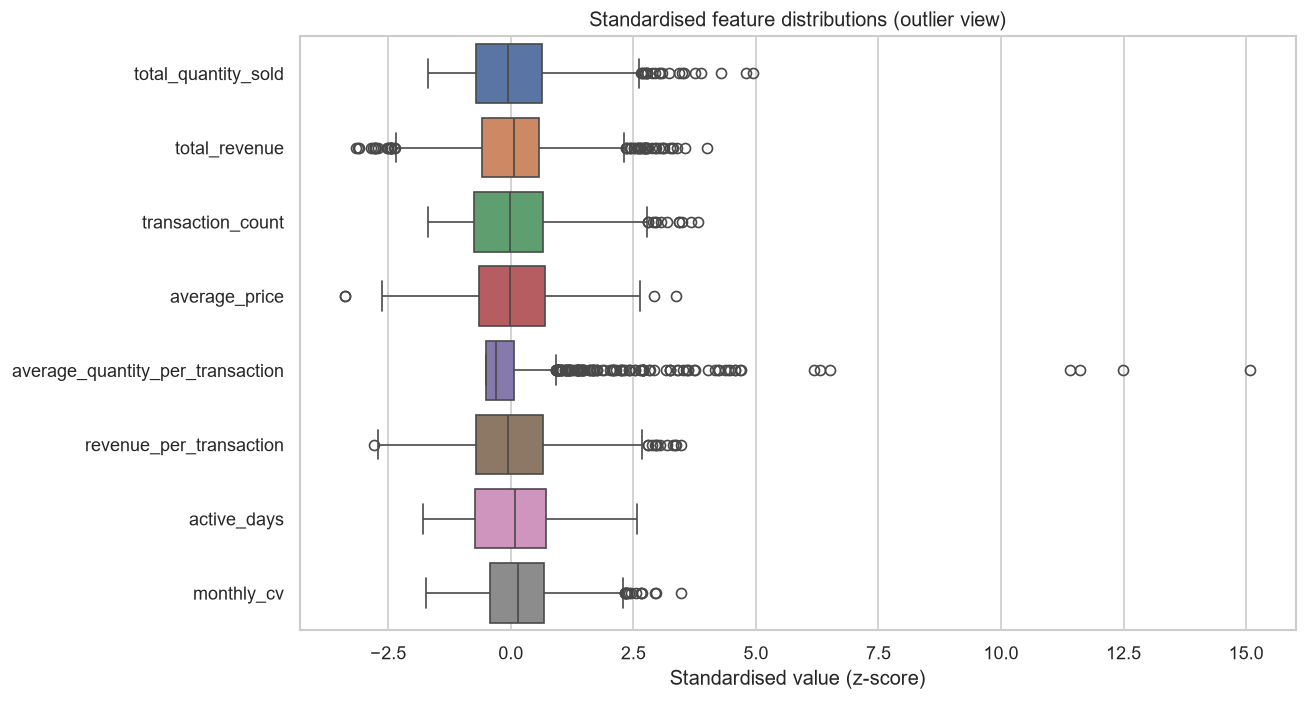

In [6]:
import numpy as np

scaled, scaler = scale_features(products)
print("Scaled matrix shape:", scaled.shape)
print("All finite (no NaN/inf):", bool(np.isfinite(scaled).all()))
display(Image(filename=str(visualization.plot_feature_boxplots(products))))

## 9. Elbow Method

Sweep k and inspect the within-cluster sum of squares (inertia).

,k,inertia,silhouette
0,2,"8,930.79",0.33
1,3,"7,470.41",0.25
2,4,"6,126.26",0.28
3,5,"5,326.29",0.28
4,6,"4,650.57",0.28
5,7,"4,163.28",0.28
6,8,"3,811.96",0.26
7,9,"3,508.07",0.26
8,10,"3,243.45",0.26


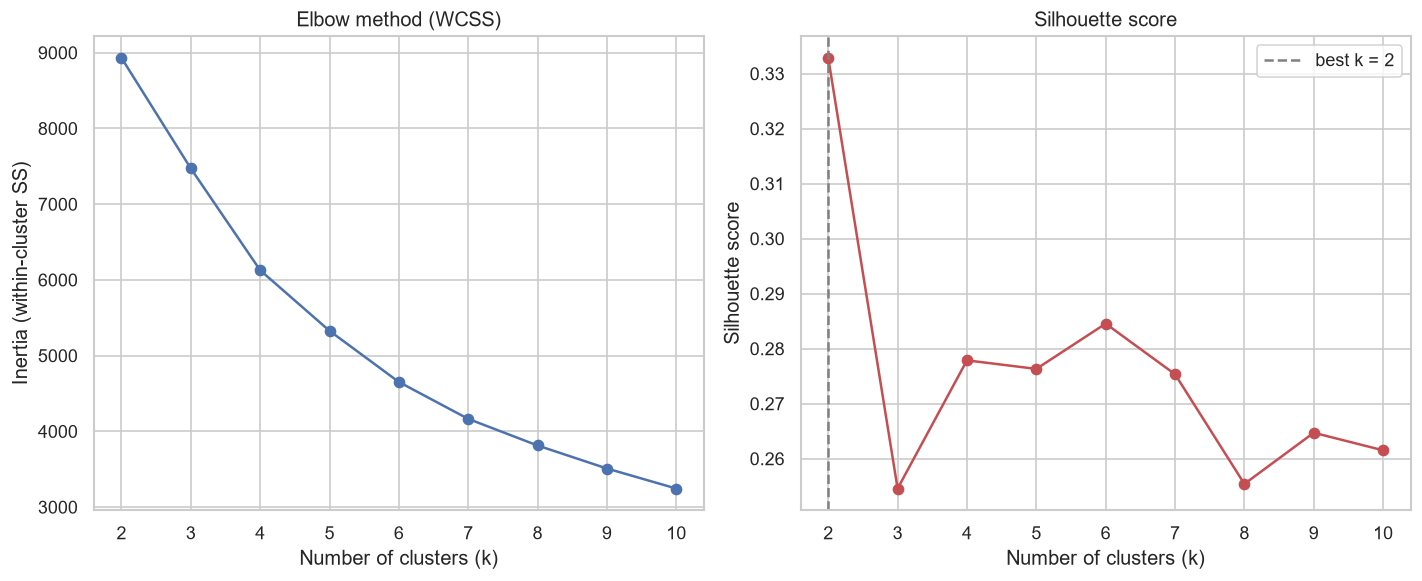

In [7]:
scores = evaluate_k(scaled)
display(scores)
display(Image(filename=str(visualization.plot_elbow_and_silhouette(scores))))

## 10. Silhouette Analysis

The silhouette score gives a single objective criterion for choosing k. We pick
the k with the highest score.

In [8]:
optimal_k = select_optimal_k(scores)
print(f"Optimal k = {optimal_k} "
      f"(silhouette = {scores['silhouette'].max():.3f})")

Optimal k = 2 (silhouette = 0.333)


## 11. K-Means Clustering

Fit the final K-Means model on the standardised features using the `k` chosen
above (`random_state=42`, `n_init=20`) and assign each product to a cluster.

In [9]:
model, labels = fit_kmeans(scaled, optimal_k)
products["cluster"] = labels
products.to_csv(config.CLUSTERED_CSV, index=False)
print(f"Fitted K-Means with k={optimal_k}; cluster sizes:")
products["cluster"].value_counts().sort_index()

Fitted K-Means with k=2; cluster sizes:


cluster
0    1014
1     721
Name: count, dtype: int64

## 12. Cluster Visualization

Project to 2-D with PCA and show cluster sizes.

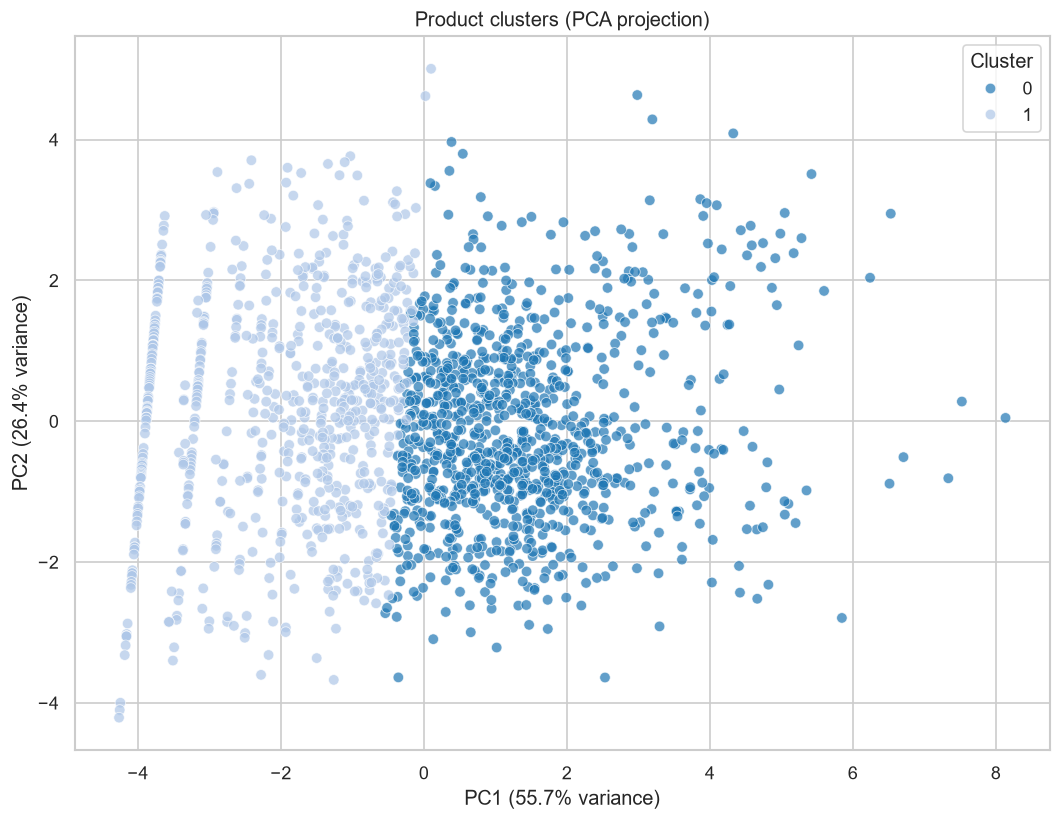

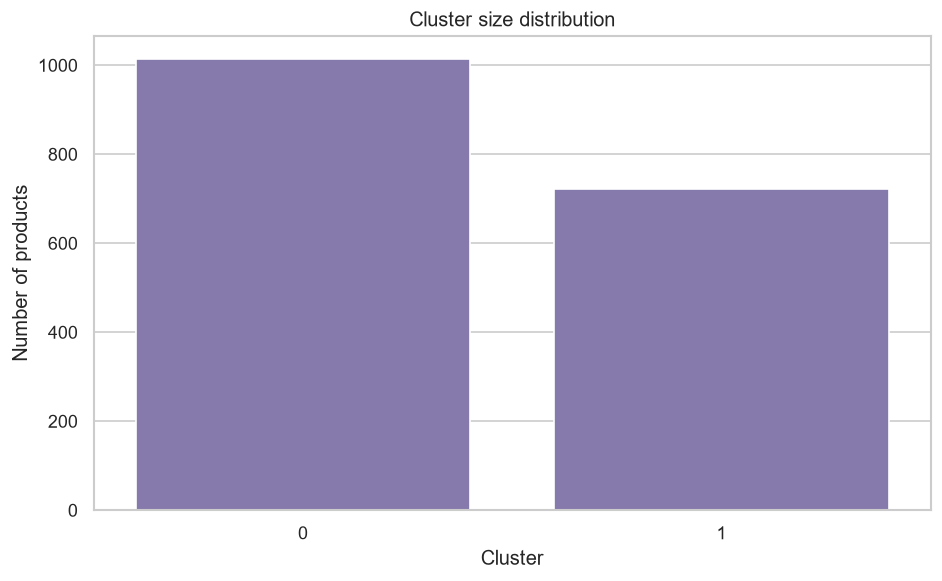

In [10]:
display(Image(filename=str(visualization.plot_pca_clusters(products))))
display(Image(filename=str(visualization.plot_cluster_sizes(products))))

## 13. Cluster Profiling

Average behaviour per cluster, used to label each segment.

In [11]:
profiles = build_cluster_profiles(products)
profiles.to_csv(config.CLUSTER_PROFILE_CSV, index=False)
profiles

,cluster,n_products,avg_quantity_sold,avg_revenue,avg_price,avg_transaction_count,avg_qty_per_txn,avg_revenue_per_txn,total_revenue,revenue_share
0,0,1014,88.95,"938,087.62","12,863.34",48.05,1.45,"16,505.37",951220850,0.93
1,1,721,5.36,"99,320.39","19,028.99",4.64,1.17,"21,816.78",71610000,0.07


### 13b. Refinement: clustering excise goods separately

Excise (cukai) goods such as cigarettes have extreme price and revenue and can
dominate the general segments. The pipeline supports clustering them in a
separate pass (`config.SEPARATE_EXCISE`). Below, each `segment_group` keeps its
own silhouette-selected k, and the profile carries the group label.

In [12]:
segmented = run_segmented_clustering(products.drop(columns="cluster"))
print(f"Total clusters across groups: {segmented.optimal_k}")
segmented.profiles

Total clusters across groups: 12


,cluster,n_products,avg_quantity_sold,avg_revenue,avg_price,avg_transaction_count,avg_qty_per_txn,avg_revenue_per_txn,total_revenue,revenue_share,segment_group
0,0,966,78.08,"533,363.87","11,279.35",39.80,1.45,"14,150.62",515229500,0.50,general
8,8,10,664.90,"17,263,640.00","24,940.46",509.40,1.28,"32,000.64",172636400,0.17,excise
5,5,7,447.43,"11,419,900.00","24,336.94",169.71,2.68,"65,165.24",79939300,0.08,excise
2,2,9,198.11,"8,186,655.56","42,241.45",174.22,1.14,"48,212.72",73679900,0.07,excise
1,1,679,5.07,"94,776.07","19,049.58",4.40,1.17,"21,855.10",64352950,0.06,general
11,11,5,138.60,"7,458,280.00","53,535.27",53.60,2.75,"132,495.48",37291400,0.04,excise
4,4,15,112.27,"2,477,353.33","22,432.19",91.13,1.23,"27,222.02",37160300,0.04,excise
9,9,16,50.75,"1,758,262.50","33,820.17",45.94,1.10,"36,984.24",28132200,0.03,excise
3,3,14,16.00,"531,300.00","34,221.96",14.07,1.15,"39,174.09",7438200,0.01,excise
10,10,3,16.00,"1,464,833.33","99,318.84",14.67,1.08,"108,008.33",4394500,0.00,excise


## 14. Business Insights

Read the profile table above and label each cluster, for example:

* **Fast-moving staples** - high quantity, high transaction count, low price.
  Keep deep stock, place at eye level, avoid stock-outs.
* **Premium / high-ticket** - high revenue per transaction, higher price, lower
  volume. Protect margin, feature in bundles, targeted promotions.
* **Long-tail / slow-movers** - low volume and revenue. Review shelf space,
  consider clearance or delisting.
* **Excise (cukai) segment** - cigarettes and similar; clustered separately
  (`segment_group == "excise"`) so their high price/revenue does not distort the
  general segments. Manage for compliance and margin.

Concrete recommendations span inventory management, promotion strategy, shelf
placement, product bundling, and stock optimisation. The narrative version lives
in `reports/final_report.md`.

In [13]:
# Programmatic helper: rank clusters by total revenue for the write-up.
summary = profiles[["cluster", "n_products", "avg_quantity_sold",
                    "avg_revenue", "avg_price", "revenue_share"]]
summary

,cluster,n_products,avg_quantity_sold,avg_revenue,avg_price,revenue_share
0,0,1014,88.95,"938,087.62","12,863.34",0.93
1,1,721,5.36,"99,320.39","19,028.99",0.07


## 15. Conclusion

We parsed 209 raw POS receipt logs into a clean transaction table, engineered
product-level features, selected k via the elbow and silhouette methods, and
trained a reproducible K-Means model (`random_state=42`). The resulting segments
are interpretable and map directly to inventory, pricing, and promotion actions.

Re-run the whole pipeline headlessly with:

```
uv run python -m src.run_pipeline
```